In [518]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

# Base learners
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Stacking
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Feature selection
from sklearn.feature_selection import VarianceThreshold

# Evaluation
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    matthews_corrcoef,
)
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Preprocessed Splits

Splits are generated by `fbs_dataset_analysis.ipynb` — run that notebook first to produce `fbs_train.csv`, `fbs_test.csv`, and `fbs_class_weights.json`.

In [519]:
TRAIN_PATH = Path("fbs_train.csv")
TEST_PATH  = Path("fbs_test.csv")
CW_PATH    = Path("fbs_class_weights.json")

for p in [TRAIN_PATH, TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f"Split file not found: {p}\n"
            "Run fbs_dataset_analysis.ipynb first to generate all split files."
        )

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

feature_cols = [c for c in train_df.columns if c not in ("label", "source")]

X_train = train_df[feature_cols].values
y_train = train_df["label"].values
X_test  = test_df[feature_cols].values
y_test  = test_df["label"].values

# Class weights computed from training data in fbs_dataset_analysis.ipynb
if CW_PATH.exists():
    with open(CW_PATH) as f:
        cw_dict = {int(k): v for k, v in json.load(f).items()}
    print(f"Class weights loaded: {cw_dict}")
else:
    cw_dict = "balanced"
    print("fbs_class_weights.json not found — falling back to class_weight='balanced'")

print(f"\nTrain : {len(train_df):,} rows  (normal={int((y_train==0).sum()):,}, attack={int((y_train==1).sum()):,})")
print(f"Test  : {len(test_df):,} rows  (normal={int((y_test==0).sum()):,}, attack={int((y_test==1).sum()):,})")
print(f"Features: {len(feature_cols)}")

Class weights loaded: {0: 0.9671113155473781, 1: 1.035204332840965}

Train : 4,205 rows  (normal=2,174, attack=2,031)
Test  : 1,052 rows  (normal=545, attack=507)
Features: 248


## 2. Data Ready

Feature selection, presence-indicator engineering, median imputation, and stratified 70/30 splitting were all performed in `fbs_dataset_analysis.ipynb`. Arrays `X_train`, `X_test` and labels are ready for scaling and training.

In [520]:
print(f"Train shape : {X_train.shape}")
print(f"Test shape  : {X_test.shape}")

Train shape : (4205, 248)
Test shape  : (1052, 248)


In [521]:
print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Features: {len(feature_cols)}")

Train : (4205, 248)  |  Test : (1052, 248)
Features: 248


## 3. LCCDE Stacking Ensemble

Based on the LCCDE framework (Western OC2 Lab, IEEE GlobeCom 2022) — three gradient boosting base learners stacked with a Logistic Regression meta-learner:

- **LightGBM** — leaf-wise splitting; best for high-dimensional sparse protocol features
- **XGBoost** — regularised boosting; strong on attack types with few unique feature patterns
- **CatBoost** — ordered boosting; resists overfitting on small per-class groups without needing OHE
- **Logistic Regression meta-learner** — learns which base model to trust per sample

Each base model captures different decision boundaries. The meta-learner resolves disagreements, especially for hard cases like `sib1_tac_attack` and `stealthy_kicking_off` variants where a single model fails.

In [522]:
# ── Base learners ──────────────────────────────────────────────────────────────
lgbm = LGBMClassifier(
    n_estimators=500,
    num_leaves=63,
    learning_rate=0.05,
    min_child_samples=2,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=2,
    eval_metric="logloss",
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42,
    verbosity=0,
)

cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    min_data_in_leaf=2,
    auto_class_weights="Balanced",
    random_state=42,
    verbose=0,
)

# ── Stacking ensemble with LR meta-learner ─────────────────────────────────────
model = StackingClassifier(
    estimators=[("lgbm", lgbm), ("xgb", xgb), ("cat", cat)],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    cv=5,
    passthrough=False,
    n_jobs=-1,
)

model.fit(X_train, y_train)
print("Stacking ensemble training complete.")
print("  Base learners : LightGBM, XGBoost, CatBoost")
print("  Meta-learner  : Logistic Regression")

/home/ubuntu-chan/Documents/Github/airgap/ids-ai-benchmark/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu-chan/Documents/Github/airgap/ids-ai-benchmark/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu-chan/Documents/Github/airgap/ids-ai-benchmark/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu-chan/Documents/Github/airgap/ids-ai-benchmark/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Stacking ensemble training complete.
  Base learners : LightGBM, XGBoost, CatBoost
  Meta-learner  : Logistic Regression


/home/ubuntu-chan/Documents/Github/airgap/ids-ai-benchmark/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [523]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    model, X_train, y_train,
    cv=cv,
    scoring=["accuracy", "f1_macro", "roc_auc"],
    n_jobs=-1,
)

print("5-Fold Cross-Validation (on training set):")
print(f"  Accuracy  : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"  F1 Macro  : {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")
print(f"  ROC-AUC   : {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")

/home/ubuntu-chan/Documents/Github/airgap/ids-ai-benchmark/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu-chan/Documents/Github/airgap/ids-ai-benchmark/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu-chan/Documents/Github/airgap/ids-ai-benchmark/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu-chan/Documents/Github/airgap/ids-ai-benchmark/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu-chan/Docume

5-Fold Cross-Validation (on training set):
  Accuracy  : 0.8975 ± 0.0056
  F1 Macro  : 0.8972 ± 0.0055
  ROC-AUC   : 0.9455 ± 0.0024


/home/ubuntu-chan/Documents/Github/airgap/ids-ai-benchmark/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu-chan/Documents/Github/airgap/ids-ai-benchmark/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu-chan/Documents/Github/airgap/ids-ai-benchmark/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu-chan/Documents/Github/airgap/ids-ai-benchmark/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu-chan/Docume

In [524]:
X_train_final = X_train
X_test_final  = X_test

print(f"Features used : {X_train_final.shape[1]}")
print(f"Train rows    : {X_train_final.shape[0]}")
print(f"Test  rows    : {X_test_final.shape[0]}")

Features used : 248
Train rows    : 4205
Test  rows    : 1052


## 6. Evaluation and Visualization

In [525]:
y_test_pred  = model.predict(X_test_final)
y_test_proba = model.predict_proba(X_test_final)[:, 1]

acc = accuracy_score(y_test, y_test_pred)
mcc = matthews_corrcoef(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_proba)

print("=" * 55)
print("Test Set (Final)")
print("=" * 55)
print(f"  Accuracy : {acc:.4f}")
print(f"  MCC      : {mcc:.4f}  (1.0 = perfect, 0 = random)")
print(f"  ROC-AUC  : {auc:.4f}")
print()
print(classification_report(y_test, y_test_pred, target_names=["Normal", "Attack"]))

Test Set (Final)
  Accuracy : 0.9030
  MCC      : 0.8061  (1.0 = perfect, 0 = random)
  ROC-AUC  : 0.9413

              precision    recall  f1-score   support

      Normal       0.89      0.92      0.91       545
      Attack       0.92      0.88      0.90       507

    accuracy                           0.90      1052
   macro avg       0.90      0.90      0.90      1052
weighted avg       0.90      0.90      0.90      1052



/home/ubuntu-chan/Documents/Github/airgap/ids-ai-benchmark/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu-chan/Documents/Github/airgap/ids-ai-benchmark/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


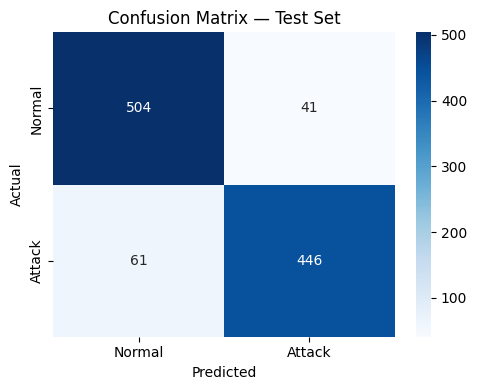

In [526]:
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

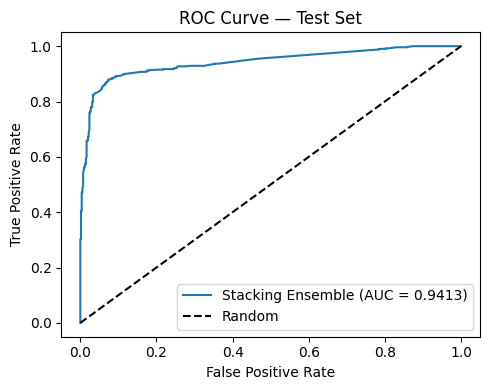

In [527]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f"Stacking Ensemble (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set")
ax.legend()
plt.tight_layout()
plt.show()

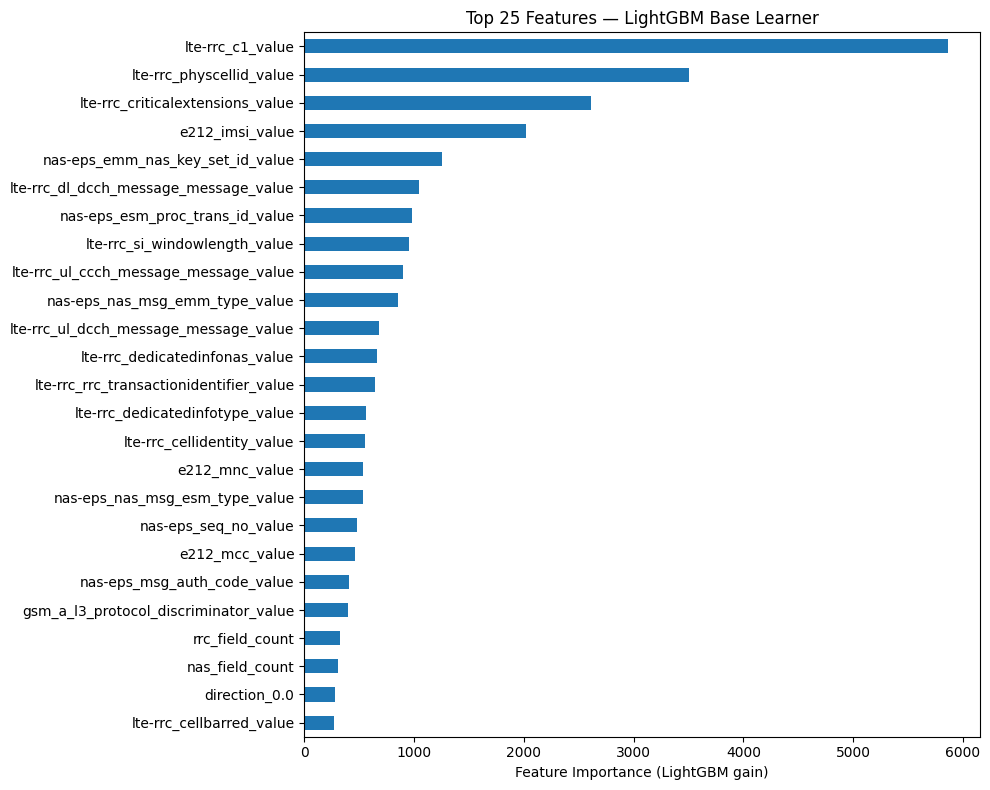


Top 10 features:
lte-rrc_c1_value                         5863
lte-rrc_physcellid_value                 3507
lte-rrc_criticalextensions_value         2615
e212_imsi_value                          2022
nas-eps_emm_nas_key_set_id_value         1253
lte-rrc_dl_dcch_message_message_value    1048
nas-eps_esm_proc_trans_id_value           983
lte-rrc_si_windowlength_value             950
lte-rrc_ul_ccch_message_message_value     903
nas-eps_nas_msg_emm_type_value            852


In [528]:
# LightGBM feature importances (gain-based) from the base learner
lgbm_model = model.named_estimators_["lgbm"]
importance  = pd.Series(lgbm_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

n_top = min(25, len(feature_cols))
fig, ax = plt.subplots(figsize=(10, 8))
importance.head(n_top).sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Feature Importance (LightGBM gain)")
ax.set_title(f"Top {n_top} Features — LightGBM Base Learner")
plt.tight_layout()
plt.show()

print(f"\nTop 10 features:")
print(importance.head(10).to_string())

In [529]:
# ── Per-attack-type accuracy breakdown ────────────────────────────────────────
# Identifies which attack types the model handles well vs misses entirely.
# With ~9 training samples per type, some types are almost certainly weak spots.

if "source" in test_df.columns:
    results = test_df[["label", "source"]].copy()
    results["predicted"] = y_test_pred
    results["correct"]   = (results["predicted"] == results["label"]).astype(int)

    summary = (
        results.groupby(["label", "source"])
        .agg(n=("correct", "count"), acc=("correct", "mean"))
        .reset_index()
        .sort_values(["label", "acc"])
    )

    print(f"{'Source':<52}  {'Class':6}  {'N':>4}  {'Acc':>6}")
    print("-" * 74)
    for _, row in summary.iterrows():
        label_str = "normal" if row["label"] == 0 else "attack"
        flag      = "  ⚠ low" if row["acc"] < 0.70 else ""
        print(f"  {row['source']:<52}  {label_str:6}  {int(row['n']):>4}  {row['acc']:>6.3f}{flag}")
else:
    print("No 'source' column in test_df — re-run fbs_dataset_analysis.ipynb to regenerate splits.")

Source                                                Class      N     Acc
--------------------------------------------------------------------------
  normal_data_20260313_172225_essential                 normal    14   0.643  ⚠ low
  normal_data6_20260313_172222_essential                normal    22   0.682  ⚠ low
  normal_data7_20260313_172220_essential                normal    15   0.733
  normal_data2_20260313_172214_essential                normal    19   0.737
  normal_data5_20260313_172219_essential                normal     8   0.750
  normal_data8_20260313_172220_essential                normal    17   0.824
  normal_data3_20260313_172214_essential                normal    12   0.917
  normal_data4_20260313_172219_essential                normal    13   0.923
  normal_data11_20260313_172226_essential               normal    67   0.940
  normal_data12_20260313_172211_essential               normal    98   0.969
  normal_data13_20260313_172216_essential               normal    